In [1]:
!pip install wordcloud

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer

from collections import Counter

import re
import ast

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to C:\Users\Krishna
[nltk_data]     Rajoo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Krishna
[nltk_data]     Rajoo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
df = pd.read_excel("C:\\Users\\Krishna Rajoo\\OneDrive\\Documents\\Top_Movies_DataSet\\Top movies.xlsx")

In [4]:
print(df['GENERES'].head())

0    ["Horror", "Mystery", "Thriller"]
1        ["Comedy", "Drama", "Family"]
2       ["Drama", "Fantasy", "Horror"]
3     ["Action", "Comedy", "Thriller"]
4      ["Action", "Comedy", "Romance"]
Name: GENERES, dtype: object


In [5]:
# Count genres per movie
df['Genre_Count'] = df['GENERES'].apply(
    lambda x: len(ast.literal_eval(x))
)

print(df['Genre_Count'].value_counts())

Genre_Count
3    601
2    271
1    128
Name: count, dtype: int64


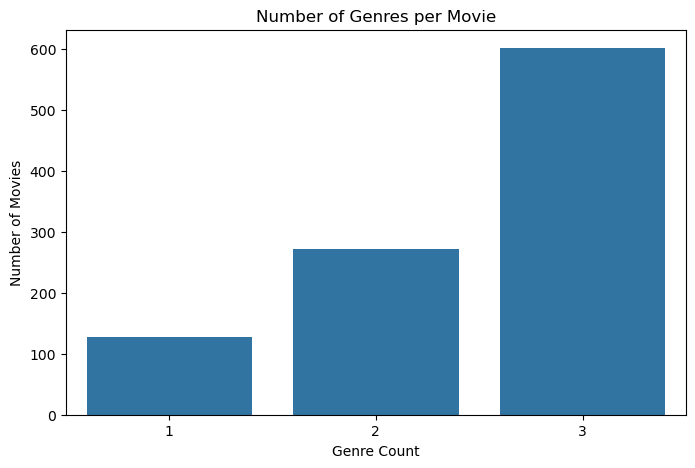

In [6]:
plt.figure(figsize=(8,5))

sns.countplot(x='Genre_Count', data=df)

plt.title("Number of Genres per Movie")

plt.xlabel("Genre Count")
plt.ylabel("Number of Movies")

plt.show()

In [7]:
# Convert string list into actual list
df['GENERES'] = df['GENERES'].apply(ast.literal_eval)

# Split into columns
genre_columns = df['GENERES'].apply(pd.Series)

# Rename columns
genre_columns.columns = [
    f'Genre_{i+1}'
    for i in genre_columns.columns
]

# Merge with original dataframe
df = pd.concat([df, genre_columns], axis=1)

print(df.head())

          ID                        TITLE                      GENERES  \
0  tt0010323  The Cabinet of Dr. Caligari  [Horror, Mystery, Thriller]   
1  tt0012349                      The Kid      [Comedy, Drama, Family]   
2  tt0012364         The Phantom Carriage     [Drama, Fantasy, Horror]   
3  tt0014429                 Safety Last!   [Action, Comedy, Thriller]   
4  tt0015324                 Sherlock Jr.    [Action, Comedy, Romance]   

   RATING   VOTES  YEAR  Genre_Count Genre_1  Genre_2   Genre_3  
0     8.0   71544  1920            3  Horror  Mystery  Thriller  
1     8.2  137306  1921            3  Comedy    Drama    Family  
2     8.0   14445  1921            3   Drama  Fantasy    Horror  
3     8.1   23398  1923            3  Action   Comedy  Thriller  
4     8.2   58766  1924            3  Action   Comedy   Romance  


In [8]:
df.head(10)

,ID,TITLE,GENERES,RATING,VOTES,YEAR,Genre_Count,Genre_1,Genre_2,Genre_3
0,tt0010323,The Cabinet of Dr. Caligari,"[Horror, Mystery, Thriller]",8.0,71544,1920,3,Horror,Mystery,Thriller
1,tt0012349,The Kid,"[Comedy, Drama, Family]",8.2,137306,1921,3,Comedy,Drama,Family
2,tt0012364,The Phantom Carriage,"[Drama, Fantasy, Horror]",8.0,14445,1921,3,Drama,Fantasy,Horror
3,tt0014429,Safety Last!,"[Action, Comedy, Thriller]",8.1,23398,1923,3,Action,Comedy,Thriller
4,tt0015324,Sherlock Jr.,"[Action, Comedy, Romance]",8.2,58766,1924,3,Action,Comedy,Romance
5,tt0015064,The Last Laugh,"[Drama, Horror]",8.0,15504,1924,2,Drama,Horror,NaN
6,tt0015881,Greed,"[Drama, Thriller, Western]",8.0,10992,1924,3,Drama,Thriller,Western
7,tt0015864,The Gold Rush,"[Adventure, Comedy, Drama]",8.1,120482,1925,3,Adventure,Comedy,Drama
8,tt0015648,Battleship Potemkin,"[Drama, History, Thriller]",7.9,62264,1925,3,Drama,History,Thriller
9,tt0017925,The General,"[Action, Adventure, Comedy]",8.1,99839,1926,3,Action,Adventure,Comedy


In [9]:
mlb = MultiLabelBinarizer()

genre_encoded = pd.DataFrame(
    mlb.fit_transform(df['GENERES']),
    columns=mlb.classes_
)

# Merge with original dataset
df = pd.concat([df, genre_encoded], axis=1)

print(df.head())

          ID                        TITLE                      GENERES  \
0  tt0010323  The Cabinet of Dr. Caligari  [Horror, Mystery, Thriller]   
1  tt0012349                      The Kid      [Comedy, Drama, Family]   
2  tt0012364         The Phantom Carriage     [Drama, Fantasy, Horror]   
3  tt0014429                 Safety Last!   [Action, Comedy, Thriller]   
4  tt0015324                 Sherlock Jr.    [Action, Comedy, Romance]   

   RATING   VOTES  YEAR  Genre_Count Genre_1  Genre_2   Genre_3  ...  Music  \
0     8.0   71544  1920            3  Horror  Mystery  Thriller  ...      0   
1     8.2  137306  1921            3  Comedy    Drama    Family  ...      0   
2     8.0   14445  1921            3   Drama  Fantasy    Horror  ...      0   
3     8.1   23398  1923            3  Action   Comedy  Thriller  ...      0   
4     8.2   58766  1924            3  Action   Comedy   Romance  ...      0   

   Musical  Mystery  News  Romance  Sci-Fi  Sport  Thriller  War  Western  
0   

In [10]:
print(df['Action'].sum())
print(df['Comedy'].sum())
print(df['Drama'].sum())

195
214
723


In [11]:
genre_totals = genre_encoded.sum().sort_values(
    ascending=False
)

print(genre_totals)

Drama          723
Crime          217
Comedy         214
Action         195
Adventure      147
Romance        133
Thriller       122
Biography      112
Documentary     86
Mystery         79
Animation       59
War             59
Fantasy         52
Sci-Fi          50
History         50
Family          43
Music           34
Sport           25
Horror          23
Film-Noir       22
Western         14
Musical         13
News             1
dtype: int64


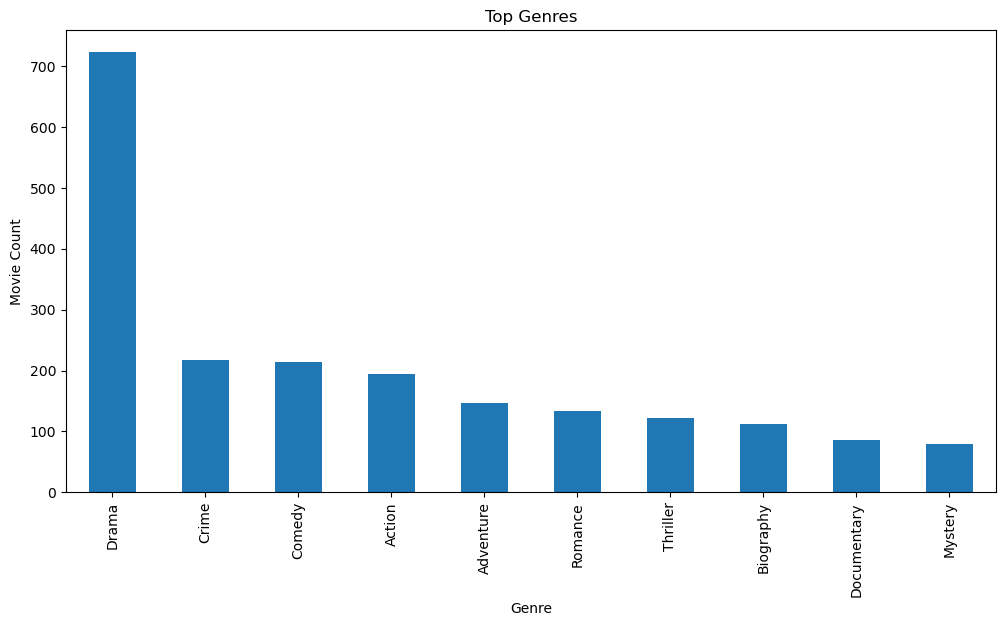

In [12]:
plt.figure(figsize=(12,6))

genre_totals.head(10).plot(kind='bar')

plt.title("Top Genres")

plt.xlabel("Genre")
plt.ylabel("Movie Count")

plt.show()

Which Genre Gets Highest Average Rating

In [13]:
genre_avg_rating = {}

for genre in mlb.classes_:

    genre_movies = df[df[genre] == 1]

    genre_avg_rating[genre] = genre_movies['RATING'].mean()

genre_avg_rating = pd.DataFrame({
    'Genre': genre_avg_rating.keys(),
    'Average_Rating': genre_avg_rating.values()
})

genre_avg_rating = genre_avg_rating.sort_values(
    by='Average_Rating',
    ascending=False
)

print(genre_avg_rating)

          Genre  Average_Rating
16         News        8.200000
21          War        8.184746
2     Animation        8.176271
22      Western        8.157143
1     Adventure        8.150340
0        Action        8.149231
15      Mystery        8.143038
4        Comedy        8.142991
8        Family        8.141860
5         Crime        8.141014
6   Documentary        8.139535
11      History        8.136000
3     Biography        8.133036
7         Drama        8.131535
14      Musical        8.130769
18       Sci-Fi        8.126000
19        Sport        8.124000
13        Music        8.123529
9       Fantasy        8.111538
17      Romance        8.102256
20     Thriller        8.098361
12       Horror        8.091304
10    Film-Noir        7.990909


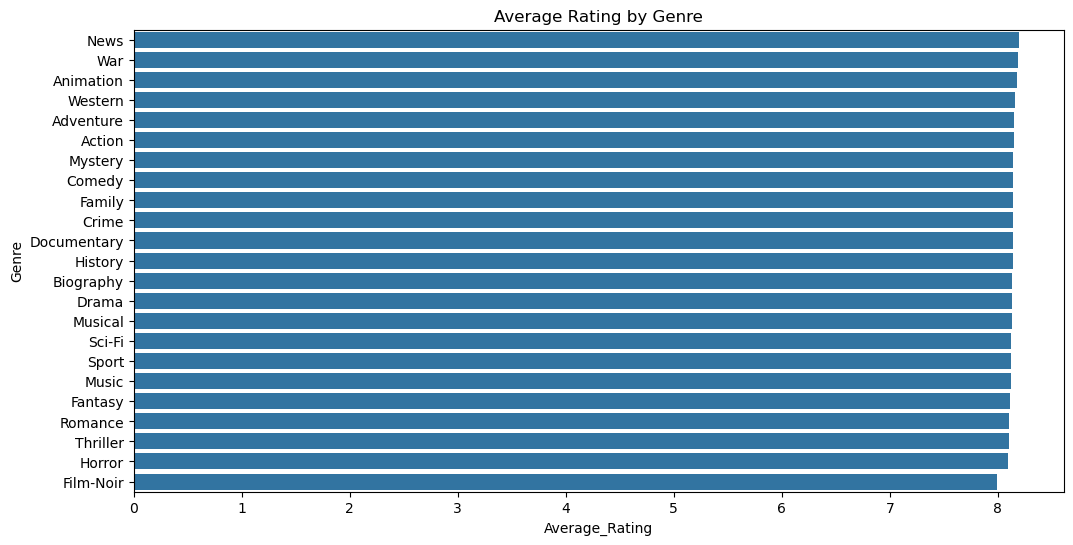

In [14]:
plt.figure(figsize=(12,6))

sns.barplot(
    x='Average_Rating',
    y='Genre',
    data=genre_avg_rating
)

plt.title("Average Rating by Genre")

plt.show()

Which Genre Gets Highest Audience Engagement

In [15]:
genre_votes = {}

for genre in mlb.classes_:

    genre_movies = df[df[genre] == 1]

    genre_votes[genre] = genre_movies['VOTES'].sum()

genre_votes = pd.DataFrame({
    'Genre': genre_votes.keys(),
    'Total_Votes': genre_votes.values()
})

genre_votes = genre_votes.sort_values(
    by='Total_Votes',
    ascending=False
)

print(genre_votes)

          Genre  Total_Votes
7         Drama    182341982
0        Action     84914376
1     Adventure     83922996
5         Crime     62117359
4        Comedy     48572492
18       Sci-Fi     38277843
20     Thriller     36832476
15      Mystery     29203697
3     Biography     27507407
2     Animation     22701569
17      Romance     21865362
9       Fantasy     21361554
21          War     12678965
8        Family      9666631
11      History      8352549
12       Horror      6415012
13        Music      5125150
22      Western      4629724
19        Sport      3554318
6   Documentary      2603062
10    Film-Noir      1796949
14      Musical       935267
16         News        29093


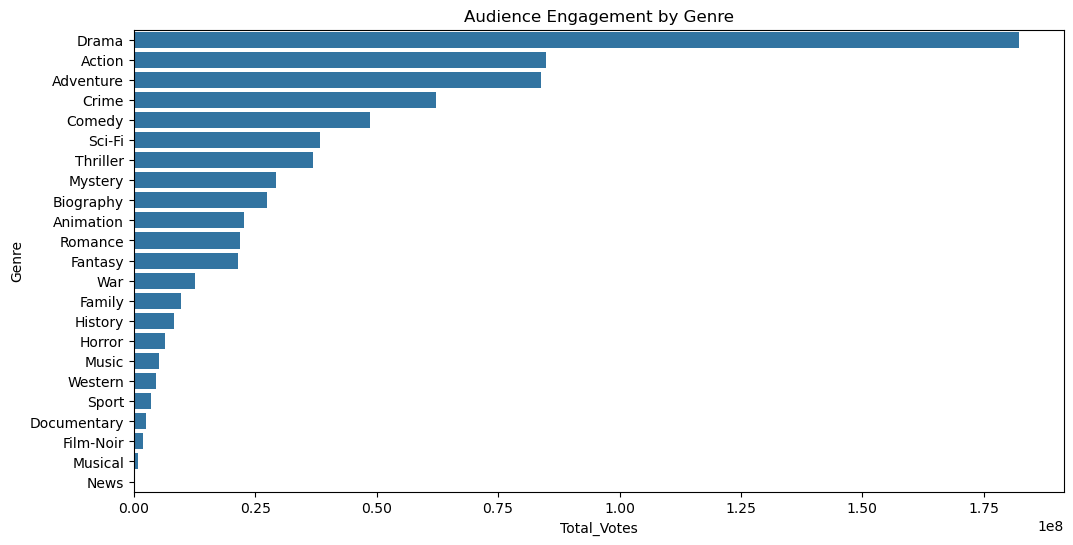

In [16]:
plt.figure(figsize=(12,6))

sns.barplot(
    x='Total_Votes',
    y='Genre',
    data=genre_votes
)

plt.title("Audience Engagement by Genre")

plt.show()

Genre Popularity Trend Over Time (MOST IMPACTFUL)

In [17]:
genre_trend = []

for genre in mlb.classes_:

    yearly_data = df[df[genre] == 1]

    yearly_count = yearly_data.groupby('YEAR').size()

    for year, count in yearly_count.items():

        genre_trend.append({
            'Genre': genre,
            'Year': year,
            'Count': count
        })

genre_trend_df = pd.DataFrame(genre_trend)

print(genre_trend_df.head())

    Genre  Year  Count
0  Action  1923      1
1  Action  1924      1
2  Action  1926      1
3  Action  1938      1
4  Action  1949      1


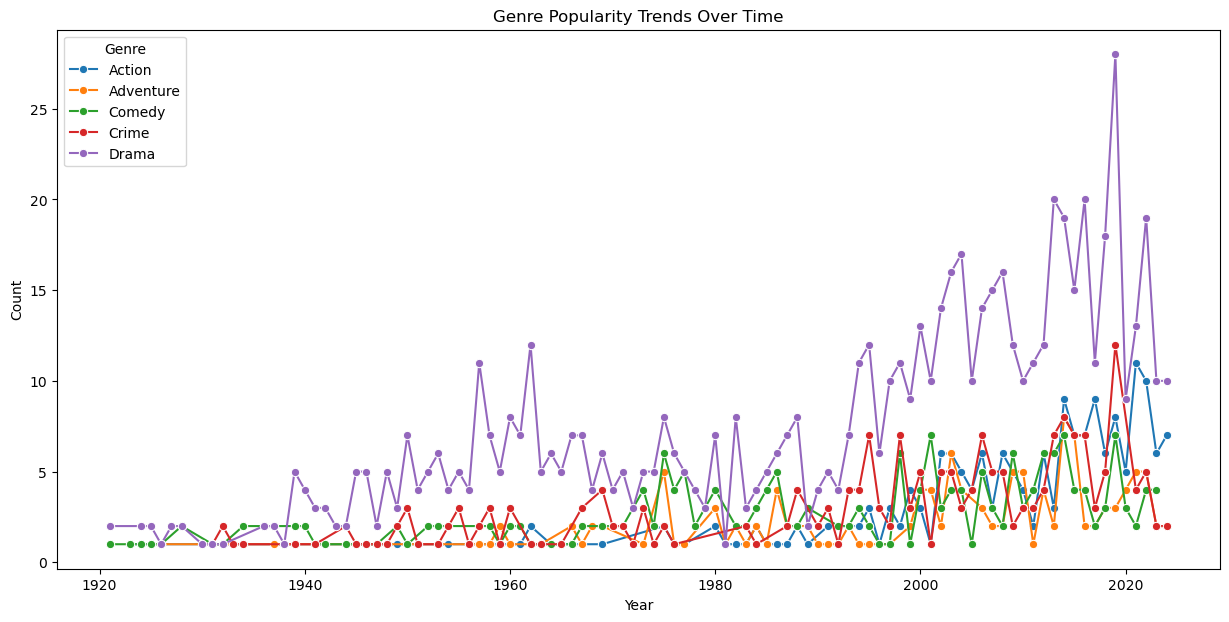

In [18]:
top5 = genre_totals.head(5).index

filtered = genre_trend_df[
    genre_trend_df['Genre'].isin(top5)
]

plt.figure(figsize=(15,7))

sns.lineplot(
    data=filtered,
    x='Year',
    y='Count',
    hue='Genre',
    marker='o'
)

plt.title("Genre Popularity Trends Over Time")

plt.show()

In [19]:
genre_corr = genre_encoded.corr()

print(genre_corr)

               Action  Adventure  Animation  Biography    Comedy     Crime  \
Action       1.000000   0.258986   0.090997  -0.070749 -0.139883  0.040933   
Adventure    0.258986   1.000000   0.315535  -0.093702  0.072589 -0.204839   
Animation    0.090997   0.315535   1.000000  -0.048555  0.045263 -0.111228   
Biography   -0.070749  -0.093702  -0.048555   1.000000 -0.154384 -0.017724   
Comedy      -0.139883   0.072589   0.045263  -0.154384  1.000000 -0.079489   
Crime        0.040933  -0.204839  -0.111228  -0.017724 -0.079489  1.000000   
Documentary -0.141969  -0.097121  -0.046533   0.185122 -0.142662 -0.031687   
Drama       -0.191674  -0.310983  -0.243319   0.007256 -0.145593  0.016854   
Family      -0.104327   0.065137   0.177057  -0.044018  0.009592 -0.111591   
Fantasy      0.043880   0.106282   0.056045  -0.083176 -0.023369 -0.112369   
Film-Noir   -0.073818  -0.062262  -0.037555  -0.053265 -0.078260  0.152589   
History     -0.043428  -0.095237  -0.057445   0.238606 -0.119707

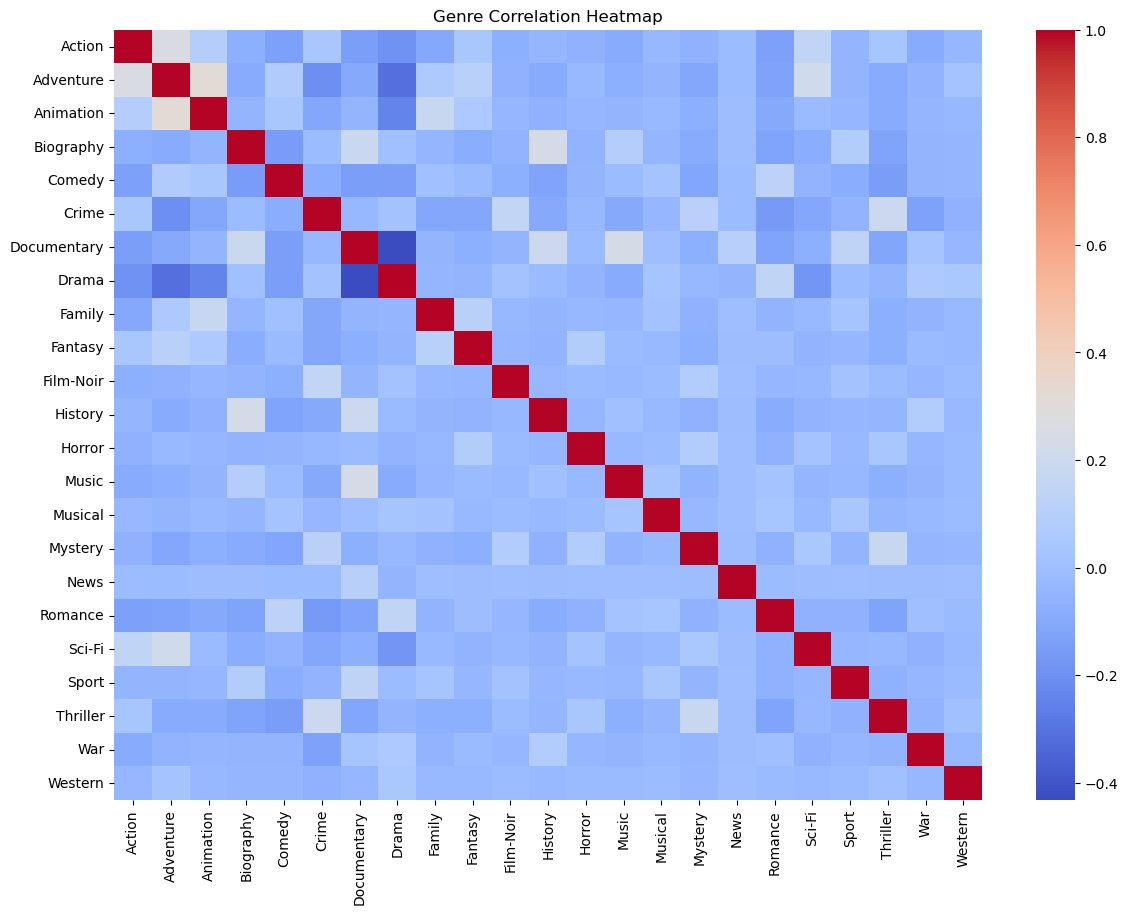

In [20]:
plt.figure(figsize=(14,10))

sns.heatmap(
    genre_corr,
    cmap='coolwarm'
)

plt.title("Genre Correlation Heatmap")

plt.show()

Top Genre Combinations

In [21]:
df['Genre_Combination'] = df['GENERES'].apply(
    lambda x: ', '.join(sorted(x))
)

combo_counts = df['Genre_Combination'].value_counts()

print(combo_counts.head(10))

Genre_Combination
Drama                        93
Drama, Romance               41
Comedy, Drama                33
Comedy, Drama, Romance       33
Action, Crime, Drama         32
Crime, Drama, Thriller       32
Crime, Drama, Mystery        22
Crime, Drama                 22
Biography, Drama, History    18
Drama, War                   18
Name: count, dtype: int64


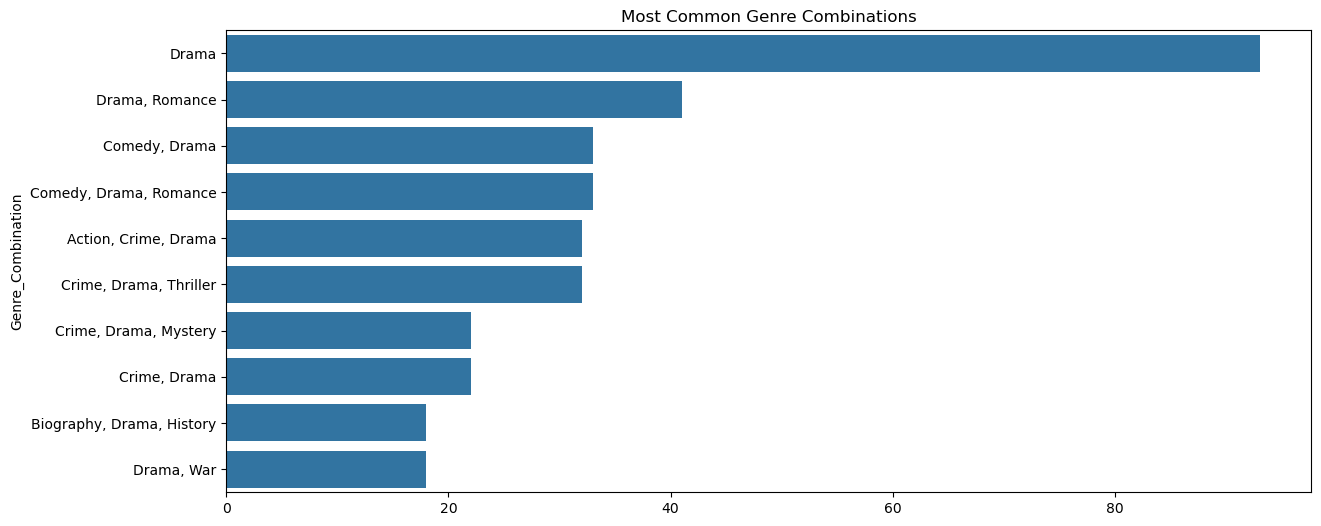

In [22]:
top_combos = combo_counts.head(10)

plt.figure(figsize=(14,6))

sns.barplot(
    x=top_combos.values,
    y=top_combos.index
)

plt.title("Most Common Genre Combinations")

plt.show()

Rating Distribution Per Genre

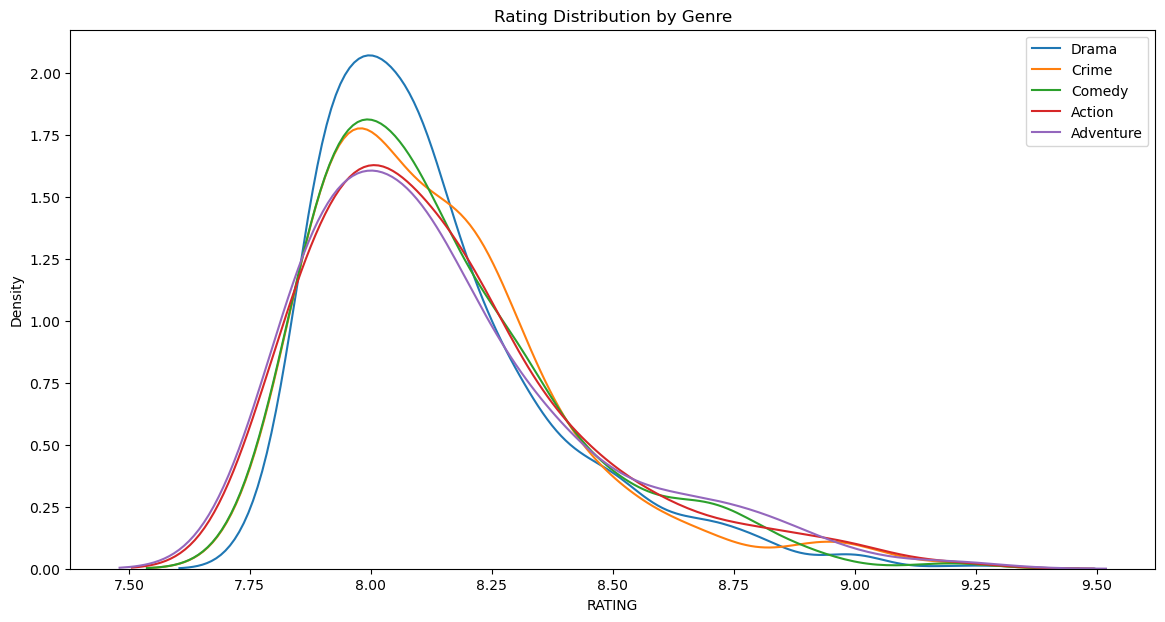

In [23]:
plt.figure(figsize=(14,7))

for genre in top5:

    sns.kdeplot(
        df[df[genre] == 1]['RATING'],
        label=genre
    )

plt.title("Rating Distribution by Genre")

plt.legend()

plt.show()

NLP-Based Keyword Analysis

In [24]:
# Stopwords
stop_words = set(stopwords.words('english'))

# Cleaning function
def clean_text(text):

    text = str(text)

    text = text.lower()

    text = re.sub(r'[^a-zA-Z]', ' ', text)

    words = word_tokenize(text)

    words = [
        word for word in words
        if word not in stop_words
    ]

    return " ".join(words)

# Create Clean_Title column
df['Clean_Title'] = df['TITLE'].apply(clean_text)

# Check output
print(df[['TITLE', 'Clean_Title']].head())

                         TITLE          Clean_Title
0  The Cabinet of Dr. Caligari  cabinet dr caligari
1                      The Kid                  kid
2         The Phantom Carriage     phantom carriage
3                 Safety Last!          safety last
4                 Sherlock Jr.          sherlock jr


In [25]:
# Combine all cleaned titles
all_words = " ".join(df['Clean_Title'])

# Split into words
word_list = all_words.split()

# Count frequency
word_freq = Counter(word_list)

# Create dataframe
word_df = pd.DataFrame(
    word_freq.items(),
    columns=['Word', 'Frequency']
)

# Sort values
word_df = word_df.sort_values(
    by='Frequency',
    ascending=False
)

# Display top words
print(word_df.head(20))

       Word  Frequency
25      man         18
94      day         12
95     life         11
177   story         10
44    night          8
120     big          8
38     king          7
133     red          7
317    love          7
31     city          7
228   blood          6
481    days          6
223    wild          6
43      one          6
726   black          6
425   class          6
461    star          6
362    time          6
7      last          6
127  street          5


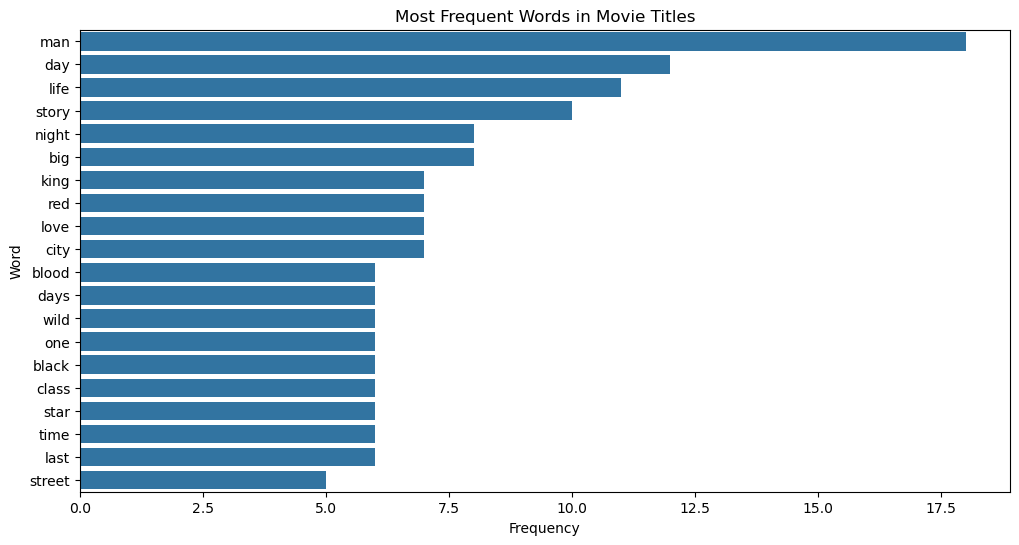

In [26]:
top_words = word_df.head(20)

plt.figure(figsize=(12,6))

sns.barplot(
    x='Frequency',
    y='Word',
    data=top_words
)

plt.title("Most Frequent Words in Movie Titles")

plt.show()

In [27]:
# TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_features=100)

X = vectorizer.fit_transform(df['Clean_Title'])

# Extract feature names
feature_names = vectorizer.get_feature_names_out()

# Average TF-IDF score
tfidf_scores = np.mean(X.toarray(), axis=0)

# Create dataframe
tfidf_df = pd.DataFrame({
    'Word': feature_names,
    'TFIDF Score': tfidf_scores
})

# Sort values
tfidf_df = tfidf_df.sort_values(
    by='TFIDF Score',
    ascending=False
)

# Display top values
print(tfidf_df.head(20))

     Word  TFIDF Score
56    man     0.015421
20    day     0.011019
52   life     0.010712
83  story     0.008049
64  night     0.006793
5     big     0.006685
16   city     0.006381
70    red     0.006346
55   love     0.006012
95   wild     0.006000
47   king     0.005903
49   last     0.005687
21   days     0.005555
7   black     0.005416
9   blood     0.005000
98  woman     0.004684
93    war     0.004684
87   time     0.004474
67    one     0.004332
60  movie     0.004204


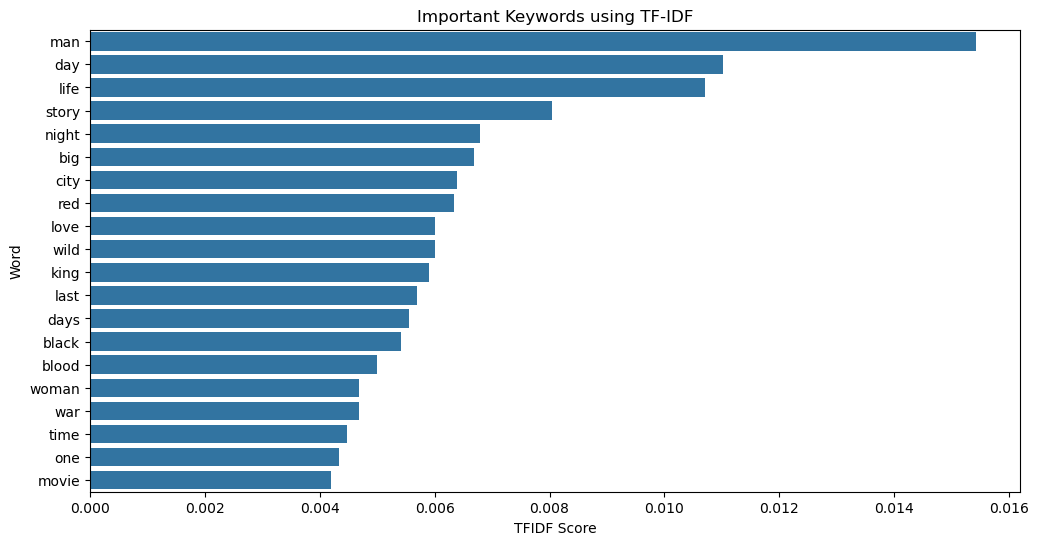

In [28]:
top_tfidf = tfidf_df.head(20)

plt.figure(figsize=(12,6))

sns.barplot(
    x='TFIDF Score',
    y='Word',
    data=top_tfidf
)

plt.title("Important Keywords using TF-IDF")

plt.show()

In [29]:
latest_year = df['YEAR'].max()

latest_movies = df[df['YEAR'] == latest_year]

latest_genres = {}

for genre in mlb.classes_:

    latest_genres[genre] = latest_movies[genre].sum()

latest_genres = pd.DataFrame({
    'Genre': latest_genres.keys(),
    'Recent_Count': latest_genres.values()
})

latest_genres = latest_genres.sort_values(
    by='Recent_Count',
    ascending=False
)

print(latest_genres.head(10))

        Genre  Recent_Count
7       Drama            10
0      Action             7
20   Thriller             3
1   Adventure             2
3   Biography             2
5       Crime             2
18     Sci-Fi             1
17    Romance             1
13      Music             1
11    History             1


In [30]:
# Find latest year in dataset
latest_year = df['YEAR'].max()

print("Latest Year in Dataset:", latest_year)

# Filter movies from latest year
latest_movies = df[df['YEAR'] == latest_year]

# Store average ratings
current_genre_ratings = {}

# Calculate average rating for each genre
for genre in mlb.classes_:

    genre_movies = latest_movies[
        latest_movies[genre] == 1
    ]

    # Avoid division error
    if len(genre_movies) > 0:

        current_genre_ratings[genre] = (
            genre_movies['RATING'].mean()
        )

# Convert to dataframe
current_genre_ratings_df = pd.DataFrame({
    'Genre': current_genre_ratings.keys(),
    'Average_Rating': current_genre_ratings.values()
})

# Sort descending
current_genre_ratings_df = current_genre_ratings_df.sort_values(
    by='Average_Rating',
    ascending=False
)

# Display results
print(current_genre_ratings_df.head(10))

Latest Year in Dataset: 2024
        Genre  Average_Rating
2   Animation        8.500000
10     Sci-Fi        8.500000
1   Adventure        8.350000
4       Crime        8.350000
9     Romance        8.300000
6       Drama        8.160000
0      Action        8.157143
11   Thriller        8.033333
7     History        8.000000
3   Biography        7.950000


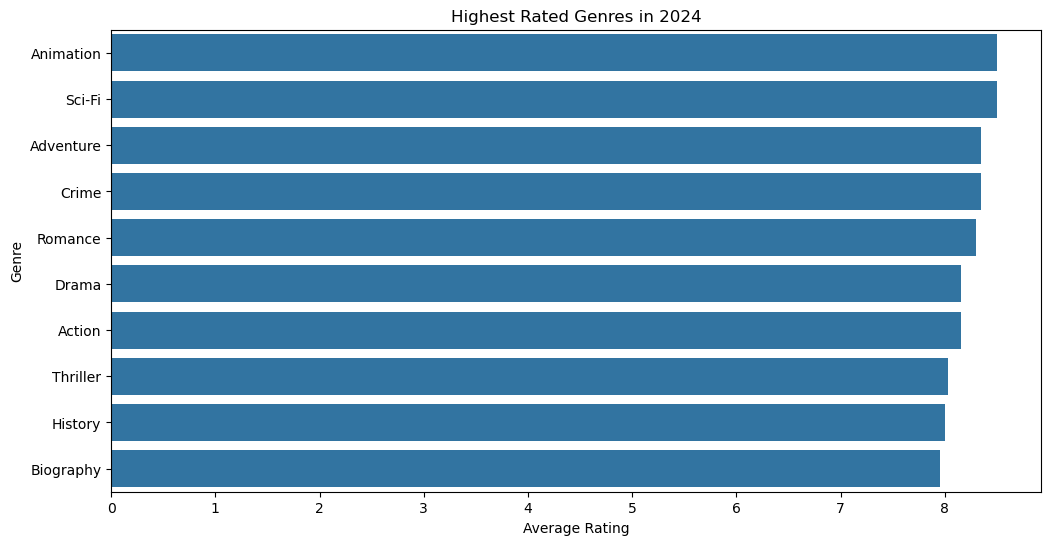

In [31]:
plt.figure(figsize=(12,6))

sns.barplot(
    x='Average_Rating',
    y='Genre',
    data=current_genre_ratings_df.head(10)
)

plt.title(
    f"Highest Rated Genres in {latest_year}"
)

plt.xlabel("Average Rating")
plt.ylabel("Genre")

plt.show()

In [32]:
# Find latest year
latest_year = df['YEAR'].max()

print("Latest Year:", latest_year)

# Filter latest year movies
latest_movies = df[df['YEAR'] == latest_year]

# Count genres
recent_genre_count = {}

for genre in mlb.classes_:

    recent_genre_count[genre] = (
        latest_movies[genre].sum()
    )

# Convert to dataframe
recent_genre_df = pd.DataFrame({
    'Genre': recent_genre_count.keys(),
    'Movie_Count': recent_genre_count.values()
})

# Sort values
recent_genre_df = recent_genre_df.sort_values(
    by='Movie_Count',
    ascending=False
)

# Display top genres
print(recent_genre_df.head(10))

Latest Year: 2024
        Genre  Movie_Count
7       Drama           10
0      Action            7
20   Thriller            3
1   Adventure            2
3   Biography            2
5       Crime            2
18     Sci-Fi            1
17    Romance            1
13      Music            1
11    History            1


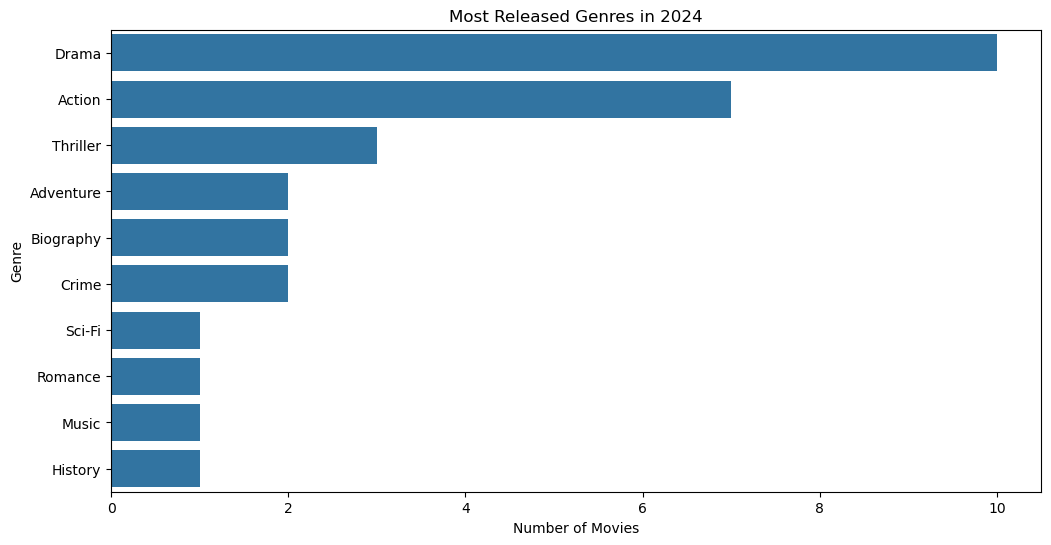

In [33]:
plt.figure(figsize=(12,6))

sns.barplot(
    x='Movie_Count',
    y='Genre',
    data=recent_genre_df.head(10)
)

plt.title(
    f"Most Released Genres in {latest_year}"
)

plt.xlabel("Number of Movies")
plt.ylabel("Genre")

plt.show()

In [34]:
# ==========================================
# MOST RELEASED GENRES IN LAST 5 YEARS
# ==========================================

latest_year = df['YEAR'].max()

recent_5_years = df[
    df['YEAR'] >= latest_year - 4
]

genre_5yr = {}

for genre in mlb.classes_:

    genre_5yr[genre] = (
        recent_5_years[genre].sum()
    )

genre_5yr_df = pd.DataFrame({
    'Genre': genre_5yr.keys(),
    'Movie_Count': genre_5yr.values()
})

genre_5yr_df = genre_5yr_df.sort_values(
    by='Movie_Count',
    ascending=False
)

print(genre_5yr_df.head(10))

          Genre  Movie_Count
7         Drama           61
0        Action           39
1     Adventure           18
3     Biography           15
4        Comedy           13
5         Crime           13
6   Documentary           13
2     Animation           11
20     Thriller            9
9       Fantasy            7


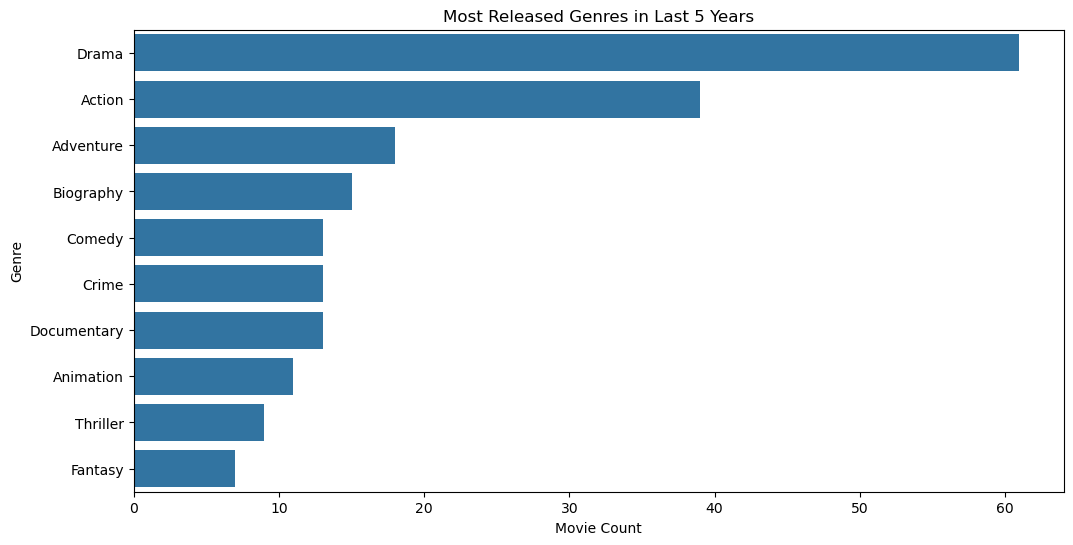

In [35]:
plt.figure(figsize=(12,6))

sns.barplot(
    x='Movie_Count',
    y='Genre',
    data=genre_5yr_df.head(10)
)

plt.title("Most Released Genres in Last 5 Years")

plt.xlabel("Movie Count")
plt.ylabel("Genre")

plt.show()

In [36]:
# =========================================================
# FINAL RESEARCH CONCLUSION OUTPUT
# =========================================================

print("\n====================================")
print(" FINAL MOVIE ANALYTICS REPORT ")
print("====================================\n")

# ---------------------------------
# Total Movies
# ---------------------------------

total_movies = len(df)

print(f"Total Movies Analysed : {total_movies}")

# ---------------------------------
# Average Rating
# ---------------------------------

avg_rating = round(df['RATING'].mean(), 2)

print(f"Average Movie Rating : {avg_rating}")

# ---------------------------------
# Most Popular Genre
# ---------------------------------

top_genre = genre_totals.idxmax()

top_genre_count = genre_totals.max()

print(
    f"Most Popular Genre : {top_genre}"
)

print(
    f"Movies in {top_genre} Genre : {top_genre_count}"
)

# ---------------------------------
# Highest Rated Genre
# ---------------------------------

highest_rated_genre = genre_avg_rating.iloc[0]

print(
    f"Highest Rated Genre : "
    f"{highest_rated_genre['Genre']}"
)

print(
    f"Average Rating : "
    f"{round(highest_rated_genre['Average_Rating'], 2)}"
)

# ---------------------------------
# Most Audience Preferred Genre
# ---------------------------------

top_vote_genre = genre_votes.iloc[0]

print(
    f"Most Audience Preferred Genre : "
    f"{top_vote_genre['Genre']}"
)

print(
    f"Total Votes : "
    f"{int(top_vote_genre['Total_Votes'])}"
)

# ---------------------------------
# Currently Trending Genre
# ---------------------------------

latest_trending = recent_genre_df.iloc[0]

print(
    f"Currently Most Released Genre : "
    f"{latest_trending['Genre']}"
)

print(
    f"Movies Released Recently : "
    f"{int(latest_trending['Movie_Count'])}"
)

# ---------------------------------
# Highest Rated Current Genre
# ---------------------------------

current_best = current_genre_ratings_df.iloc[0]

print(
    f"Currently Highest Rated Genre : "
    f"{current_best['Genre']}"
)

print(
    f"Current Average Rating : "
    f"{round(current_best['Average_Rating'], 2)}"
)

# ---------------------------------
# Most Common Genre Combination
# ---------------------------------

top_combo = combo_counts.index[0]

top_combo_count = combo_counts.iloc[0]

print(
    f"Most Common Genre Combination : "
    f"{top_combo}"
)

print(
    f"Combination Count : "
    f"{top_combo_count}"
)

# ---------------------------------
# NLP Insights
# ---------------------------------

top_word = word_df.iloc[0]

print(
    f"Most Frequent Keyword in Titles : "
    f"{top_word['Word']}"
)

print(
    f"Keyword Frequency : "
    f"{top_word['Frequency']}"
)

top_tfidf_word = tfidf_df.iloc[0]

print(
    f"Most Important TF-IDF Keyword : "
    f"{top_tfidf_word['Word']}"
)

# ---------------------------------
# Final Conclusion
# ---------------------------------

print("\n====================================")
print(" FINAL RESEARCH CONCLUSION ")
print("====================================\n")

print(
    f"The analysis reveals that "
    f"{top_genre} is the dominant genre "
    f"in the movie industry based on "
    f"overall movie production."
)

print(
    f"{highest_rated_genre['Genre']} "
    f"receives the highest average ratings, "
    f"indicating strong audience appreciation."
)

print(
    f"Recent trend analysis shows that "
    f"{latest_trending['Genre']} is currently "
    f"the most actively released genre."
)

print(
    f"NLP-based text analysis identified "
    f"'{top_word['Word']}' as the most frequent "
    f"keyword in movie titles."
)

print(
    "The project successfully combines "
    "data analytics, NLP techniques, and "
    "visualization to identify meaningful "
    "patterns in movie industry trends."
)

print("\n====================================")
print(" PROJECT COMPLETED SUCCESSFULLY ")
print("====================================")


 FINAL MOVIE ANALYTICS REPORT 

Total Movies Analysed : 1000
Average Movie Rating : 8.14
Most Popular Genre : Drama
Movies in Drama Genre : 723
Highest Rated Genre : News
Average Rating : 8.2
Most Audience Preferred Genre : Drama
Total Votes : 182341982
Currently Most Released Genre : Drama
Movies Released Recently : 10
Currently Highest Rated Genre : Animation
Current Average Rating : 8.5
Most Common Genre Combination : Drama
Combination Count : 93
Most Frequent Keyword in Titles : man
Keyword Frequency : 18
Most Important TF-IDF Keyword : man

 FINAL RESEARCH CONCLUSION 

The analysis reveals that Drama is the dominant genre in the movie industry based on overall movie production.
News receives the highest average ratings, indicating strong audience appreciation.
Recent trend analysis shows that Drama is currently the most actively released genre.
NLP-based text analysis identified 'man' as the most frequent keyword in movie titles.
The project successfully combines data analytics, 

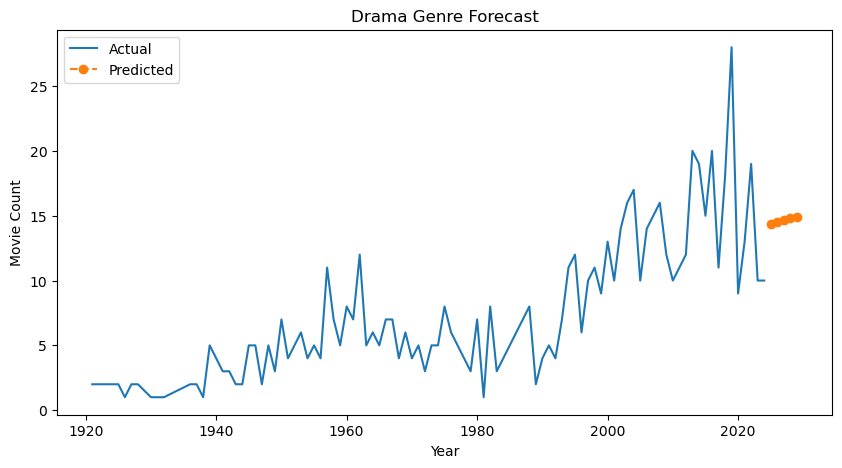

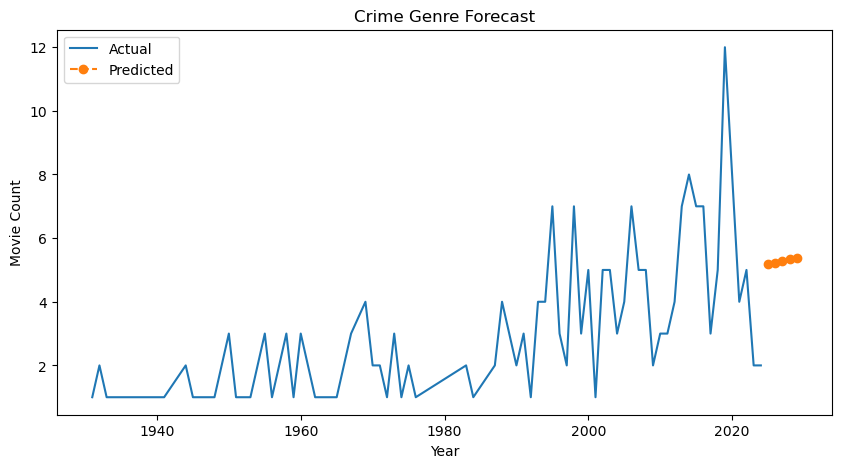

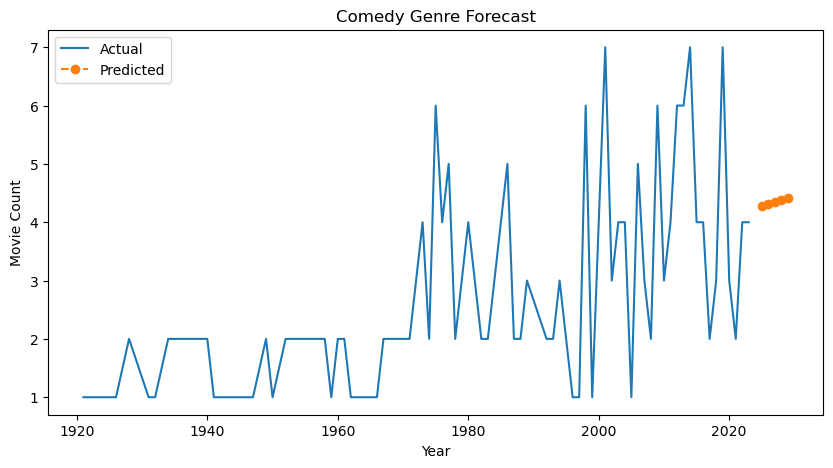

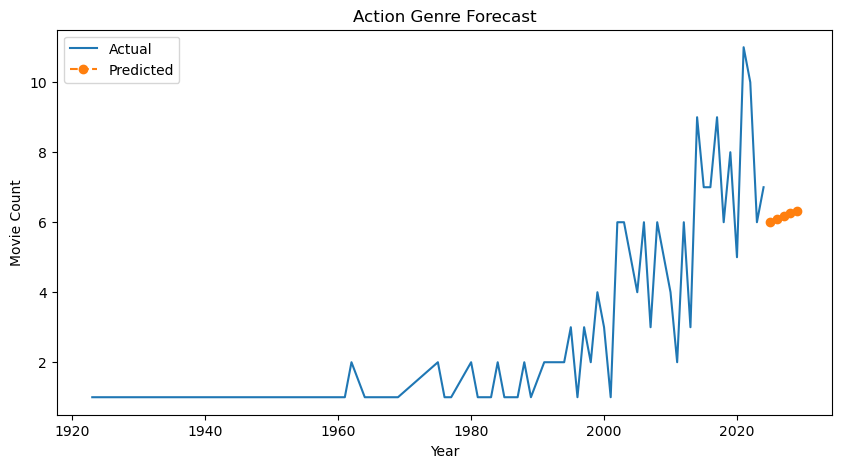

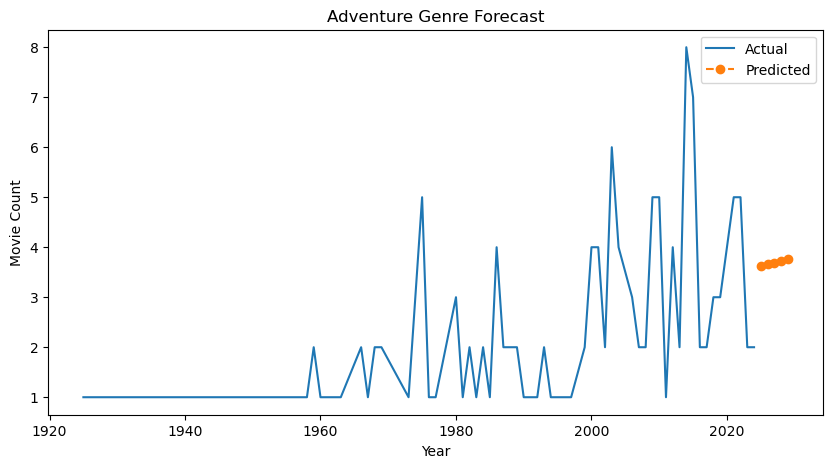

In [37]:
# =========================================================
# GENRE FORECASTING
# =========================================================

from sklearn.linear_model import LinearRegression
import numpy as np

# Select top genres
top_genres = genre_totals.head(5).index

for genre in top_genres:

    # Yearly counts
    yearly = df[df[genre] == 1].groupby('YEAR').size()

    years = np.array(yearly.index).reshape(-1, 1)

    counts = np.array(yearly.values)

    # Train model
    model = LinearRegression()

    model.fit(years, counts)

    # Predict next 5 years
    future_years = np.array(
        range(df['YEAR'].max() + 1,
              df['YEAR'].max() + 6)
    ).reshape(-1, 1)

    predictions = model.predict(future_years)

    # Plot
    plt.figure(figsize=(10,5))

    plt.plot(years, counts, label='Actual')

    plt.plot(
        future_years,
        predictions,
        linestyle='dashed',
        marker='o',
        label='Predicted'
    )

    plt.title(f"{genre} Genre Forecast")

    plt.xlabel("Year")

    plt.ylabel("Movie Count")

    plt.legend()

    plt.show()

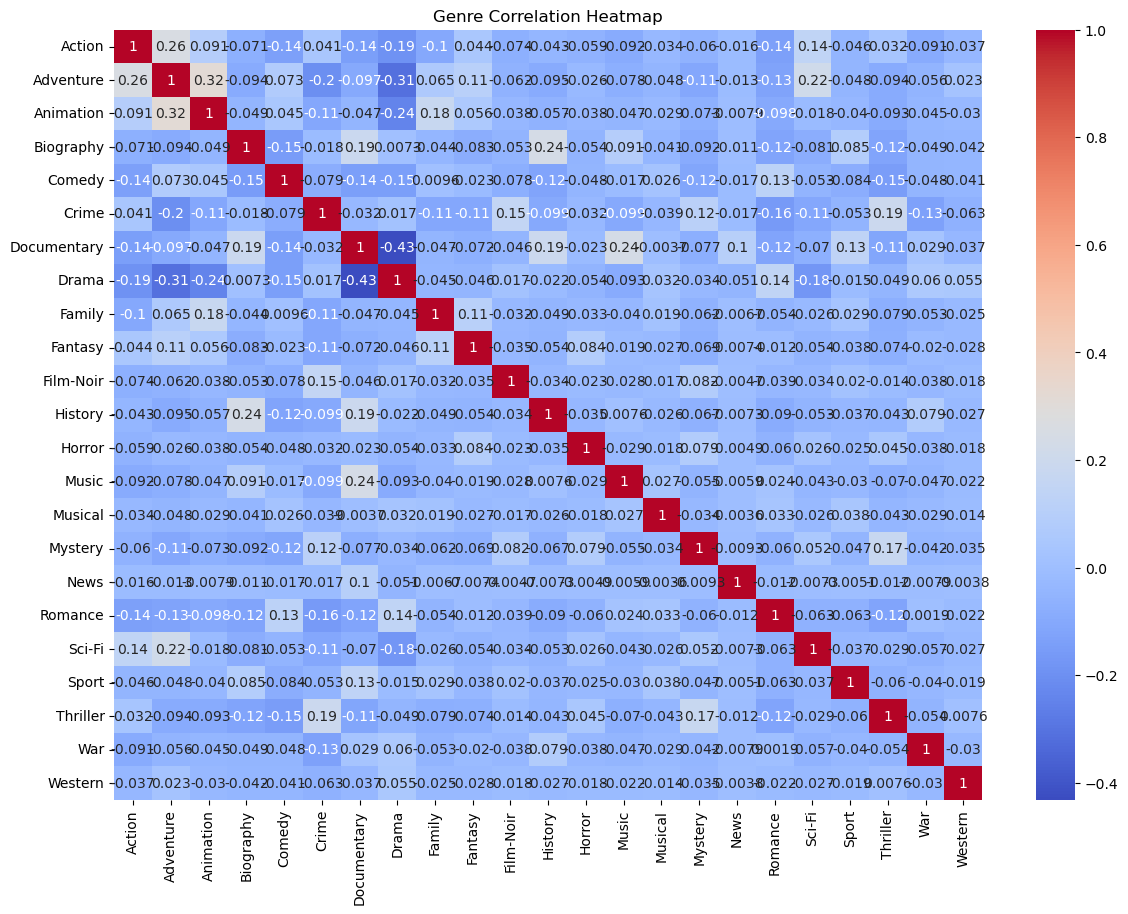

In [38]:
# =========================================================
# GENRE CORRELATION HEATMAP
# =========================================================

genre_corr = genre_encoded.corr()

plt.figure(figsize=(14,10))

sns.heatmap(
    genre_corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Genre Correlation Heatmap")

plt.show()

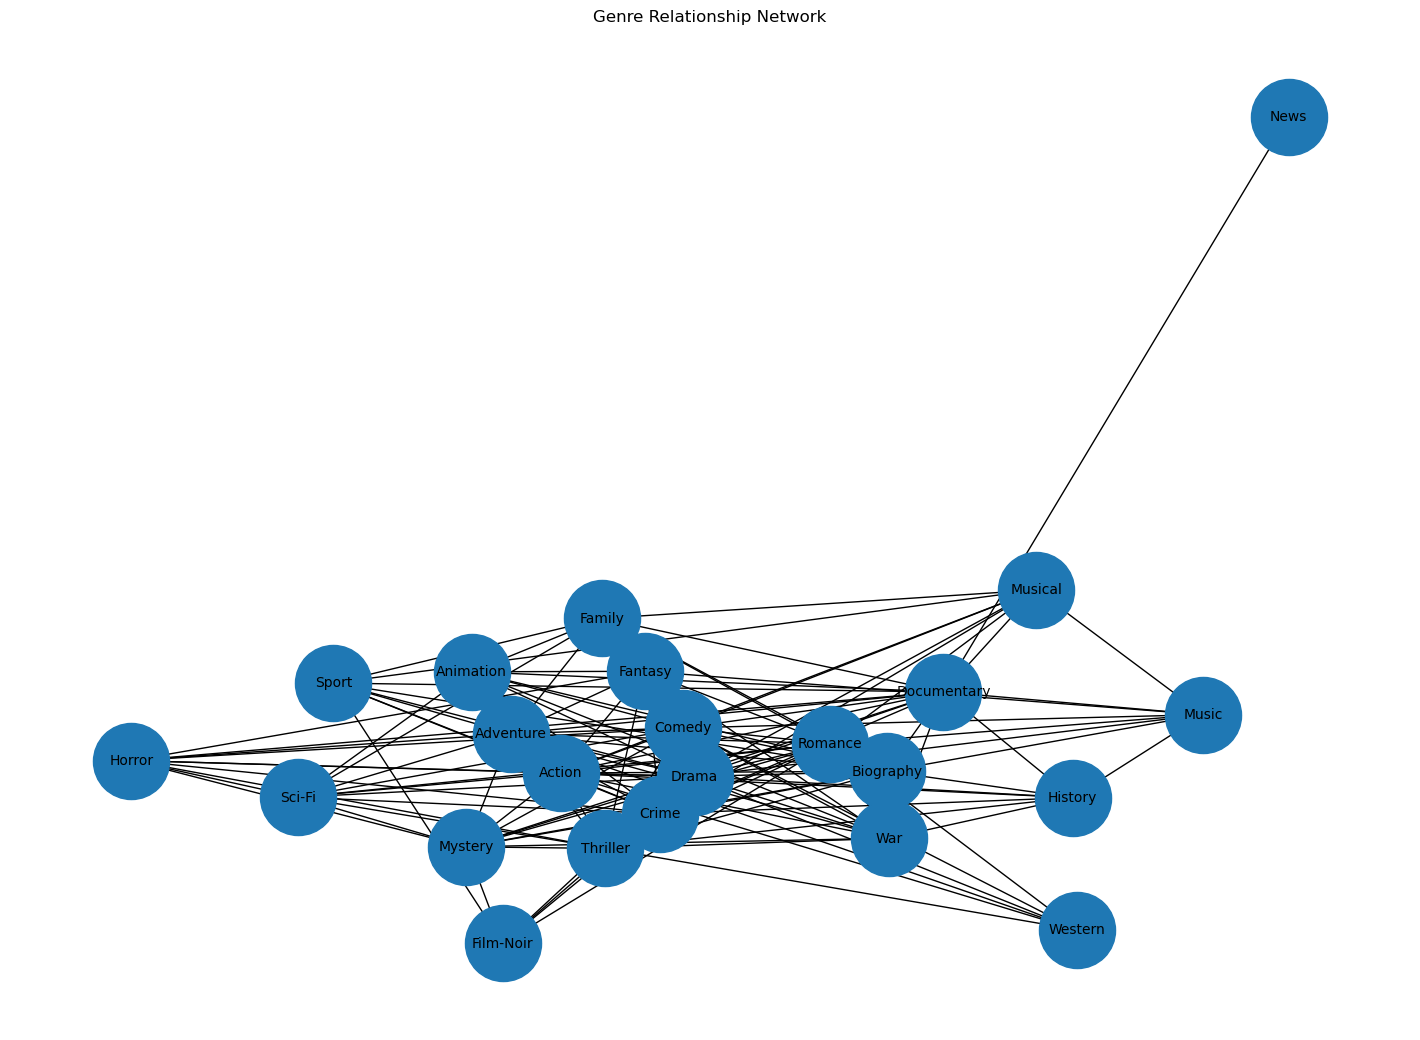

In [39]:
# =========================================================
# GENRE NETWORK GRAPH
# =========================================================

import networkx as nx
from itertools import combinations

# Create graph
G = nx.Graph()

# Add connections
for genres in df['GENERES']:

    for g1, g2 in combinations(genres, 2):

        if G.has_edge(g1, g2):

            G[g1][g2]['weight'] += 1

        else:

            G.add_edge(g1, g2, weight=1)

# Draw graph
plt.figure(figsize=(14,10))

pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=3000,
    font_size=10
)

plt.title("Genre Relationship Network")

plt.show()

In [40]:
# =========================================================
# OUTLIER ANALYSIS
# =========================================================

# High votes but low ratings
outliers = df[
    (df['VOTES'] > df['VOTES'].quantile(0.90)) &
    (df['RATING'] < df['RATING'].mean())
]

print(outliers[
    ['TITLE', 'RATING', 'VOTES']
].head(10))

                                                 TITLE  RATING    VOTES
327                                     The Terminator     8.1   942450
451                                            Titanic     7.9  1308370
459                                   The Big Lebowski     8.1   873159
501                                     Monsters, Inc.     8.1  1000546
504                                       Donnie Darko     8.0   864017
518                                Catch Me If You Can     8.1  1123845
534  Pirates of the Caribbean: The Curse of the Bla...     8.1  1233841
578                                     V for Vendetta     8.1  1193910
609                                        Ratatouille     8.1   851082
632                                Slumdog Millionaire     8.0   885150


C:\Users\Krishna Rajoo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


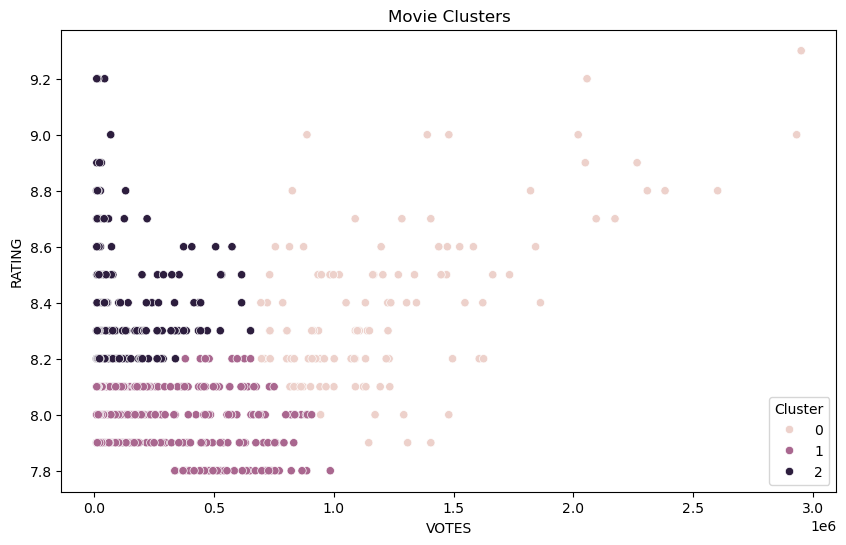

In [41]:
# =========================================================
# MOVIE CLUSTERING
# =========================================================

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Features
X = df[['RATING', 'VOTES']]

# Scale data
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# KMeans
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

df['Cluster'] = kmeans.fit_predict(X_scaled)

# Visualization
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='VOTES',
    y='RATING',
    hue='Cluster',
    data=df
)

plt.title("Movie Clusters")

plt.show()

In [42]:
# =========================================================
# TOP MOVIES PER GENRE
# =========================================================

for genre in top_genres:

    print("\n================================")

    print(f"Top {genre} Movies")

    print("================================")

    top_movies = df[df[genre] == 1] \
        .sort_values(
            by='RATING',
            ascending=False
        ) \
        [['TITLE', 'RATING']] \
        .head(5)

    print(top_movies)


Top Drama Movies
                        TITLE  RATING
405  The Shawshank Redemption     9.3
232             The Godfather     9.2
626           The Dark Knight     9.0
243     The Godfather Part II     9.0
971                     Kaiva     9.0

Top Crime Movies
                     TITLE  RATING
232          The Godfather     9.2
626        The Dark Knight     9.0
243  The Godfather Part II     9.0
118           12 Angry Men     9.0
804            Mirror Game     8.9

Top Comedy Movies
                                TITLE  RATING
250                   The Chaos Class     9.2
263                       Tosun Pasha     8.9
251  The Chaos Class Failed the Class     8.9
307               The Marathon Family     8.8
265               The Foster Brothers     8.8

Top Action Movies
                                             TITLE  RATING
394            Ramayana: The Legend of Prince Rama     9.2
971                                          Kaiva     9.0
626                                

In [43]:
# =========================================================
# GENRE GROWTH RATE
# =========================================================

growth_data = []

for genre in top_genres:

    yearly = df[df[genre] == 1].groupby('YEAR').size()

    if len(yearly) > 1:

        growth = (
            (yearly.iloc[-1] - yearly.iloc[0])
            / yearly.iloc[0]
        ) * 100

        growth_data.append({
            'Genre': genre,
            'Growth %': growth
        })

growth_df = pd.DataFrame(growth_data)

growth_df = growth_df.sort_values(
    by='Growth %',
    ascending=False
)

print(growth_df)

       Genre  Growth %
3     Action     600.0
0      Drama     400.0
2     Comedy     300.0
1      Crime     100.0
4  Adventure     100.0


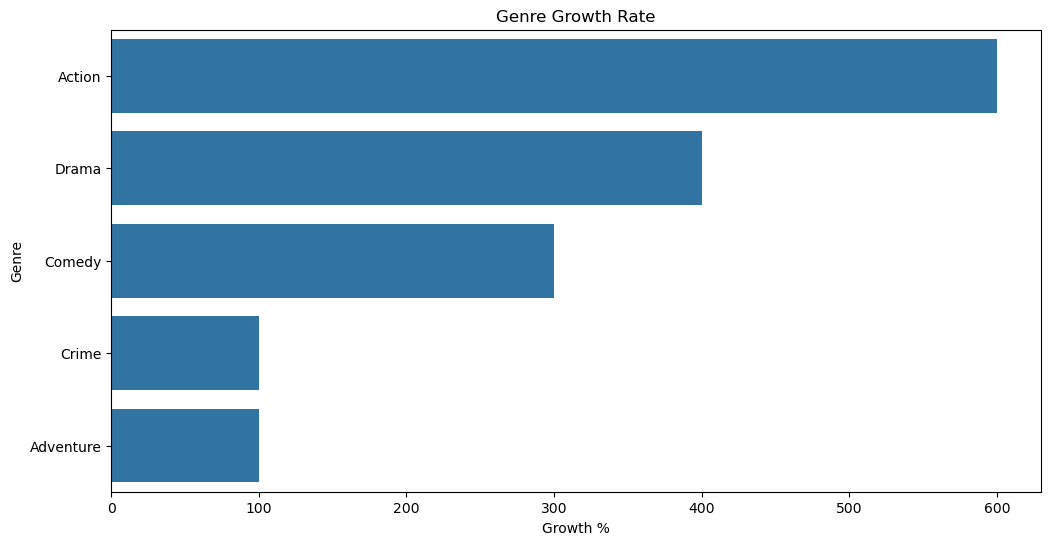

In [44]:
plt.figure(figsize=(12,6))

sns.barplot(
    x='Growth %',
    y='Genre',
    data=growth_df
)

plt.title("Genre Growth Rate")

plt.show()

In [45]:
# =========================================================
# ADVANCED RESEARCH INSIGHTS
# =========================================================

print("\n===================================")
print(" ADVANCED RESEARCH INSIGHTS ")
print("===================================\n")

fastest_growing = growth_df.iloc[0]

print(
    f"Fastest Growing Genre : "
    f"{fastest_growing['Genre']}"
)

print(
    f"Growth Percentage : "
    f"{round(fastest_growing['Growth %'], 2)}%"
)

largest_cluster = df['Cluster'].value_counts().idxmax()

print(
    f"Dominant Movie Cluster : "
    f"Cluster {largest_cluster}"
)

print(
    "Genre relationship analysis "
    "revealed strong co-occurrence "
    "patterns among multiple genres."
)

print(
    "Forecasting analysis indicates "
    "future genre production trends "
    "based on historical movie data."
)

print(
    "Clustering successfully identified "
    "distinct categories of movies "
    "based on audience engagement "
    "and ratings."
)

print("\n===================================")
print(" ADVANCED ANALYSIS COMPLETED ")
print("===================================")


 ADVANCED RESEARCH INSIGHTS 

Fastest Growing Genre : Action
Growth Percentage : 600.0%
Dominant Movie Cluster : Cluster 1
Genre relationship analysis revealed strong co-occurrence patterns among multiple genres.
Forecasting analysis indicates future genre production trends based on historical movie data.
Clustering successfully identified distinct categories of movies based on audience engagement and ratings.

 ADVANCED ANALYSIS COMPLETED 


In [46]:
# =========================================================
# EXPORT FINAL DATASETS FOR POWER BI
# =========================================================

# Main cleaned dataset
df.to_csv(
    "C:\\Users\\Krishna Rajoo\\OneDrive\\Documents\\Top_Movies_DataSet\\final_movie_dataset.csv",
    index=False
)

# Genre average ratings
genre_avg_rating.to_csv(
    "C:\\Users\\Krishna Rajoo\\OneDrive\\Documents\\Top_Movies_DataSet\\genre_avg_rating.csv",
    index=False
)

# Genre audience engagement
genre_votes.to_csv(
    "C:\\Users\\Krishna Rajoo\\OneDrive\\Documents\\Top_Movies_DataSet\\genre_votes.csv",
    index=False
)

# Genre growth analysis
growth_df.to_csv(
    "C:\\Users\\Krishna Rajoo\\OneDrive\\Documents\\Top_Movies_DataSet\\genre_growth.csv",
    index=False
)

# Genre yearly trends
genre_trend_df.to_csv(
    "C:\\Users\\Krishna Rajoo\\OneDrive\\Documents\\Top_Movies_DataSet\\genre_trend.csv",
    index=False
)

# TF-IDF analysis
tfidf_df.to_csv(
    "C:\\Users\\Krishna Rajoo\\OneDrive\\Documents\\Top_Movies_DataSet\\tfidf_analysis.csv",
    index=False
)

# Word frequency analysis
word_df.to_csv(
    "C:\\Users\\Krishna Rajoo\\OneDrive\\Documents\\Top_Movies_DataSet\\word_frequency.csv",
    index=False
)

# Genre combinations
combo_counts.to_csv(
    "C:\\Users\\Krishna Rajoo\\OneDrive\\Documents\\Top_Movies_DataSet\\genre_combinations.csv"
)

# Current trending genres
recent_genre_df.to_csv(
    "C:\\Users\\Krishna Rajoo\\OneDrive\\Documents\\Top_Movies_DataSet\\recent_genres.csv",
    index=False
)

# Current highest rated genres
current_genre_ratings_df.to_csv(
    "C:\\Users\\Krishna Rajoo\\OneDrive\\Documents\\Top_Movies_DataSet\\current_genre_ratings.csv",
    index=False
)

print("\n===================================")
print(" ALL FILES EXPORTED SUCCESSFULLY ")
print("===================================\n")

print("Exported Files:")

print("1. final_movie_dataset.csv")
print("2. genre_avg_rating.csv")
print("3. genre_votes.csv")
print("4. genre_growth.csv")
print("5. genre_trend.csv")
print("6. tfidf_analysis.csv")
print("7. word_frequency.csv")
print("8. genre_combinations.csv")
print("9. recent_genres.csv")
print("10. current_genre_ratings.csv")


 ALL FILES EXPORTED SUCCESSFULLY 

Exported Files:
1. final_movie_dataset.csv
2. genre_avg_rating.csv
3. genre_votes.csv
4. genre_growth.csv
5. genre_trend.csv
6. tfidf_analysis.csv
7. word_frequency.csv
8. genre_combinations.csv
9. recent_genres.csv
10. current_genre_ratings.csv
